In [39]:
!pip install nltk

In [40]:
import nltk
import string
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import gutenberg, webtext, stopwords, reuters, movie_reviews, state_union
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import LancasterStemmer, PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.probability import FreqDist
from nltk.util import ngrams
from wordcloud import WordCloud

In [41]:
nltk.download('all')
nltk.download('punkt_tab')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

In [42]:
display(gutenberg.fileids())
display(webtext.fileids())
print(stopwords.words('english')) #glue words, carry little to no unique meaning,
                                  #Stopwords='stop' processing highly frequent low-value 'words' to save storage space and processing time

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

['firefox.txt',
 'grail.txt',
 'overheard.txt',
 'pirates.txt',
 'singles.txt',
 'wine.txt']

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [43]:
#Stemming- chops off end of word (suffixes and prefixes). Fast
#Lemmatization- morphological analysis of word,context,part of speech (lemma).High accuracy, preserves meaning
#ngrams- sequence of n items(words,letters or syllables), bigrams and trigrams are better. not to lose context

In [44]:
#Task-1
import nltk
from nltk.corpus import reuters, movie_reviews
display(reuters.categories())
display(movie_reviews.fileids())

['acq',
 'alum',
 'barley',
 'bop',
 'carcass',
 'castor-oil',
 'cocoa',
 'coconut',
 'coconut-oil',
 'coffee',
 'copper',
 'copra-cake',
 'corn',
 'cotton',
 'cotton-oil',
 'cpi',
 'cpu',
 'crude',
 'dfl',
 'dlr',
 'dmk',
 'earn',
 'fuel',
 'gas',
 'gnp',
 'gold',
 'grain',
 'groundnut',
 'groundnut-oil',
 'heat',
 'hog',
 'housing',
 'income',
 'instal-debt',
 'interest',
 'ipi',
 'iron-steel',
 'jet',
 'jobs',
 'l-cattle',
 'lead',
 'lei',
 'lin-oil',
 'livestock',
 'lumber',
 'meal-feed',
 'money-fx',
 'money-supply',
 'naphtha',
 'nat-gas',
 'nickel',
 'nkr',
 'nzdlr',
 'oat',
 'oilseed',
 'orange',
 'palladium',
 'palm-oil',
 'palmkernel',
 'pet-chem',
 'platinum',
 'potato',
 'propane',
 'rand',
 'rape-oil',
 'rapeseed',
 'reserves',
 'retail',
 'rice',
 'rubber',
 'rye',
 'ship',
 'silver',
 'sorghum',
 'soy-meal',
 'soy-oil',
 'soybean',
 'strategic-metal',
 'sugar',
 'sun-meal',
 'sun-oil',
 'sunseed',
 'tea',
 'tin',
 'trade',
 'veg-oil',
 'wheat',
 'wpi',
 'yen',
 'zinc']

['neg/cv000_29416.txt',
 'neg/cv001_19502.txt',
 'neg/cv002_17424.txt',
 'neg/cv003_12683.txt',
 'neg/cv004_12641.txt',
 'neg/cv005_29357.txt',
 'neg/cv006_17022.txt',
 'neg/cv007_4992.txt',
 'neg/cv008_29326.txt',
 'neg/cv009_29417.txt',
 'neg/cv010_29063.txt',
 'neg/cv011_13044.txt',
 'neg/cv012_29411.txt',
 'neg/cv013_10494.txt',
 'neg/cv014_15600.txt',
 'neg/cv015_29356.txt',
 'neg/cv016_4348.txt',
 'neg/cv017_23487.txt',
 'neg/cv018_21672.txt',
 'neg/cv019_16117.txt',
 'neg/cv020_9234.txt',
 'neg/cv021_17313.txt',
 'neg/cv022_14227.txt',
 'neg/cv023_13847.txt',
 'neg/cv024_7033.txt',
 'neg/cv025_29825.txt',
 'neg/cv026_29229.txt',
 'neg/cv027_26270.txt',
 'neg/cv028_26964.txt',
 'neg/cv029_19943.txt',
 'neg/cv030_22893.txt',
 'neg/cv031_19540.txt',
 'neg/cv032_23718.txt',
 'neg/cv033_25680.txt',
 'neg/cv034_29446.txt',
 'neg/cv035_3343.txt',
 'neg/cv036_18385.txt',
 'neg/cv037_19798.txt',
 'neg/cv038_9781.txt',
 'neg/cv039_5963.txt',
 'neg/cv040_8829.txt',
 'neg/cv041_22364.txt',


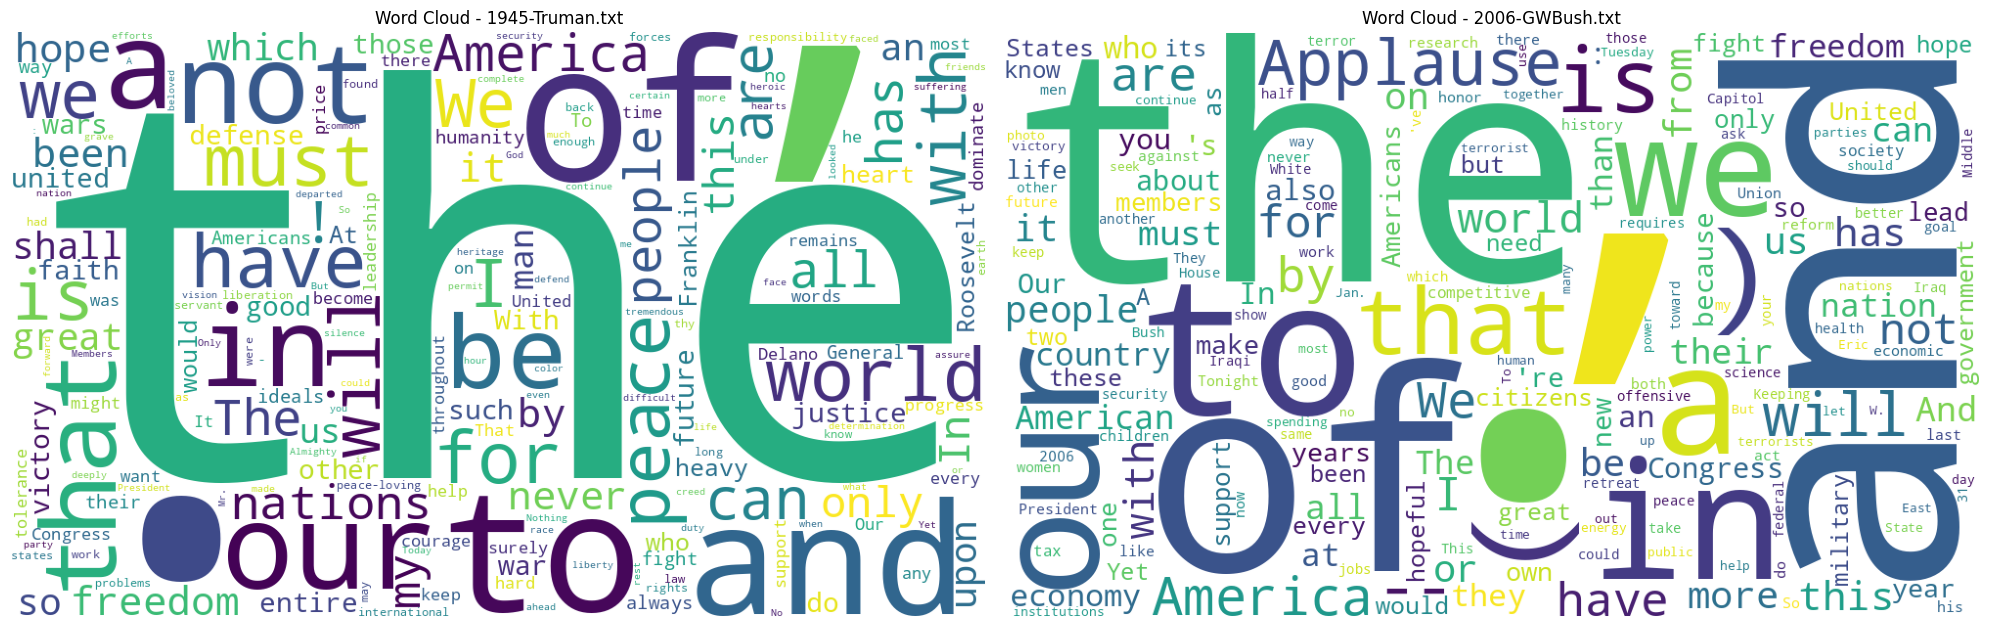

In [45]:
#Task-2
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import state_union
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

su_a=state_union.fileids()[0]
su_b=state_union.fileids()[-1]

file_a = state_union.raw(su_a)
file_b = state_union.raw(su_b)

file1 = word_tokenize(file_a)
file2 = word_tokenize(file_b)

fd1 = FreqDist(file1)
fd2 = FreqDist(file2)

wc1 = WordCloud(width=1000, height=600, background_color='white')
cloud1 = wc1.generate_from_frequencies(fd1)

wc2 = WordCloud(width=1000, height=600, background_color='white')
cloud2 = wc2.generate_from_frequencies(fd2)

plt.figure(figsize = (20,10))

plt.subplot(1, 2, 1)
plt.imshow(cloud1)
plt.axis('off')
plt.title(f"Word Cloud - {su_a}")

plt.subplot(1, 2, 2)
plt.imshow(cloud2)
plt.axis('off')
plt.title(f"Word Cloud - {su_b}")

plt.tight_layout()
plt.show()

[',', '.', "'s", 'movie', 'know', 'like', 'baldwin', 'ship', "n't", 'robot', 'curtis', '(', ')', 'crew', 'kick', 'power', 'going', 'gore', 'really', 'course']
[18, 14, 9, 5, 4, 4, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


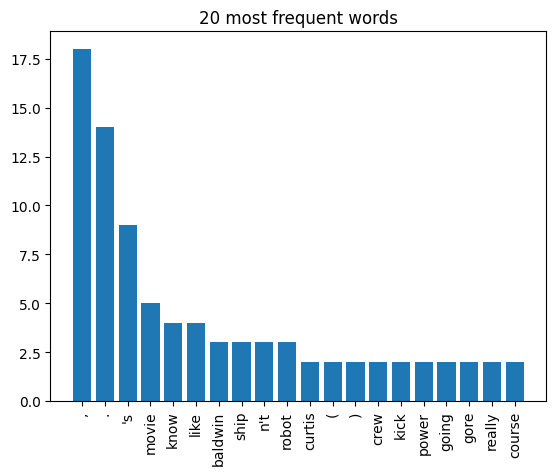

In [52]:
#Task-3
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.corpus import movie_reviews
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist

text = movie_reviews.raw(movie_reviews.fileids(categories=['neg'])[1])
t_text = word_tokenize(text)

stop_words = stopwords.words('english')
filtered_words = []
for w in t_text:
  if w.lower() not in stop_words:
    filtered_words.append(w.lower())

lemmatizer = WordNetLemmatizer()
lemmatized_word = []
for word in filtered_words:
  lemmatized_word.append(lemmatizer.lemmatize(word))

word_count = FreqDist(lemmatized_word)
word = []
count = []
for tup in word_count.most_common(20):
  word.append(tup[0])
  count.append(tup[1])
print(word)
print(count)

plt.bar(word,count)
plt.xticks(rotation=90)
plt.title("20 most frequent words")
plt.show()

In [47]:
#Task-4
import nltk
import string
import numpy as np
from nltk.corpus import reuters
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.util import ngrams

text=reuters.raw(reuters.fileids()[0])

text_low=text.lower()

text_low_nopun = text_low.translate(str.maketrans('', '', string.punctuation))
#no_pun = []
#for w in words: if w.lower() not in string.punctuation: no_pun.append(w)

words = word_tokenize(text_low_nopun)

stop_words = stopwords.words('english')
filtered_words = []
for w in words:
  if w.lower() not in stop_words:
    filtered_words.append(w)

word_count = FreqDist(filtered_words)
word = []
count = []
for tup in word_count.most_common(12):
  word.append(tup[0])
  count.append(tup[1])

bigrams = list(ngrams(filtered_words, n = 2))


matrix = np.zeros((len(word), len(word)), dtype=int)

word_to_index = {}

for i, w in enumerate(word):
    word_to_index[w] = i

print(word_to_index)

for i,j in bigrams:
  if i in word and j in word:
    matrix[word_to_index[i], word_to_index[j]] += 1

print(matrix)

{'us': 0, 'said': 1, 'trade': 2, 'japan': 3, 'dlrs': 4, 'exports': 5, 'imports': 6, 'tariffs': 7, 'billion': 8, 'businessmen': 9, 'might': 10, 'japanese': 11}
[[0 3 1 3 0 1 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 3 0]
 [1 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 5 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]]


In [48]:
#Task-5
import nltk
from nltk.corpus import udhr
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.util import ngrams

#udhr.fileids()
text=udhr.raw('German_Deutsch-Latin1')
words = word_tokenize(text)


vowel = ['a','e','i','o','u','ä','ö','ü']
filtered_words = []
for w in words:
  sv=[]
  for v in w:
    if v.lower() in vowel:
      sv.append(v.lower())
  if len(sv)>=3:
    trigrams = list(ngrams(sv, 3))
    filtered_words.extend(trigrams)


word_count = FreqDist(filtered_words)
sorted_list = word_count.most_common()
sorted_list
#word = []
#count = []
#for tup in word_count:
#  word.append(tup[0])
#  count.append(tup[1])
#plt.bar(word,count)

[(('e', 'i', 'e'), 164),
 (('e', 'e', 'i'), 42),
 (('i', 'e', 'e'), 39),
 (('e', 'e', 'e'), 37),
 (('i', 'e', 'i'), 37),
 (('a', 'i', 'e'), 34),
 (('i', 'e', 'a'), 22),
 (('i', 'i', 'e'), 21),
 (('e', 'a', 'e'), 19),
 (('a', 'e', 'e'), 18),
 (('u', 'e', 'i'), 18),
 (('a', 'e', 'i'), 17),
 (('e', 'i', 'i'), 15),
 (('e', 'o', 'e'), 14),
 (('i', 'a', 'e'), 14),
 (('a', 'a', 'e'), 14),
 (('u', 'e', 'e'), 14),
 (('e', 'i', 'u'), 14),
 (('a', 'i', 'o'), 13),
 (('a', 'u', 'e'), 11),
 (('o', 'i', 'e'), 11),
 (('e', 'e', 'u'), 10),
 (('e', 'i', 'a'), 10),
 (('u', 'a', 'e'), 9),
 (('i', 'e', 'u'), 9),
 (('i', 'u', 'e'), 9),
 (('e', 'e', 'a'), 9),
 (('o', 'e', 'i'), 8),
 (('o', 'i', 'a'), 8),
 (('o', 'a', 'e'), 8),
 (('e', 'ä', 'u'), 7),
 (('e', 'a', 'u'), 7),
 (('i', 'o', 'e'), 7),
 (('e', 'ä', 'i'), 7),
 (('e', 'a', 'a'), 7),
 (('i', 'o', 'a'), 7),
 (('ä', 'i', 'e'), 7),
 (('e', 'o', 'u'), 6),
 (('e', 'u', 'e'), 6),
 (('a', 'e', 'a'), 6),
 (('e', 'a', 'i'), 6),
 (('e', 'ä', 'e'), 6),
 (('ö', 'e